# **RNN and LSTM**

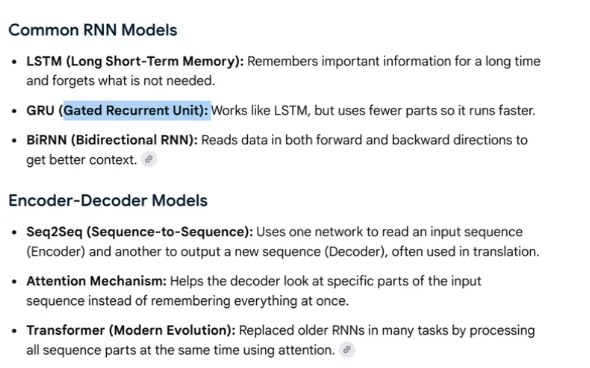

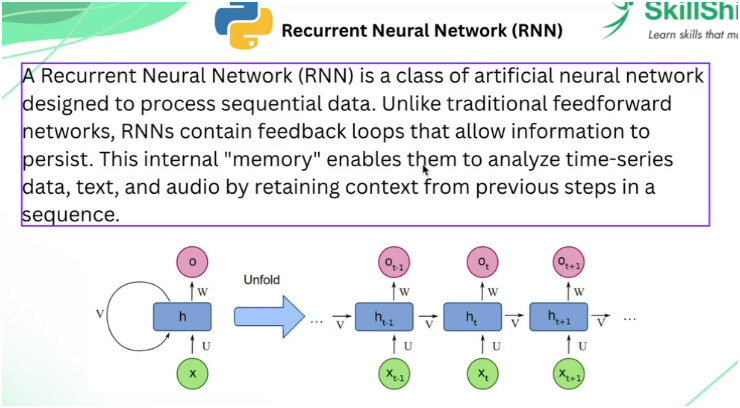

**Limitations:**

- Short term memory

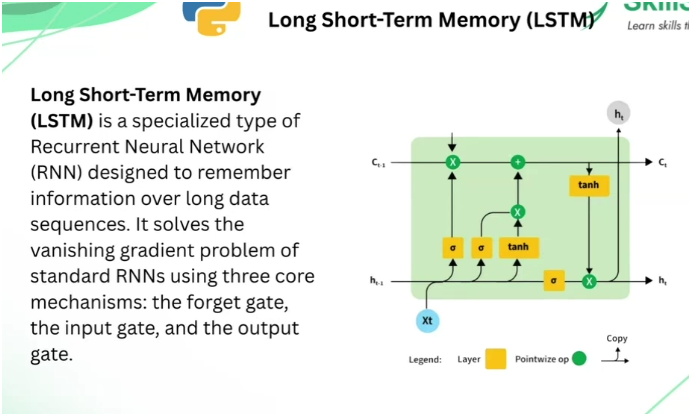

**tanh, sigmoid function are non-linear activation function, (X, + )  are gates**

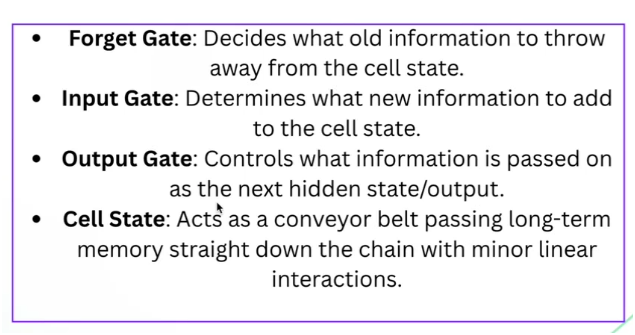

**Comparison of ANN and RNN**

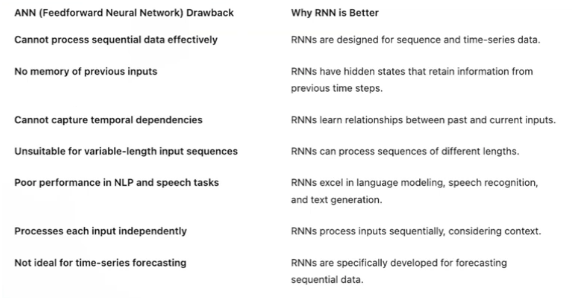

**Use cases of LSTM**

- time series forecasting
- natural language processing
- health care

# **Code starts from here**

- **keras dataset for weather forecasting [Jena Climate LSTM Forecasting (Tensorflow / Keras)]**

In [1]:
import tensorflow as tf

In [2]:
print("Tensorflow:",tf.__version__)
print("GPUs:",tf.config.list_physical_devices("GPU"))

Tensorflow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras


In [4]:
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)


13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
df.shape

(420551, 15)

*using temperature as target*

In [7]:
series = df["T (degC)"].values.reshape(-1,1)
series.shape

(420551, 1)

*using MinMaxScaler for normalization*

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

series = scaler.fit_transform(series)

In [11]:
TIME_STEPS  = 72

X = []
y = []

for i in range(len(series) - TIME_STEPS):
  X.append(series[i:i+TIME_STEPS])
  y.append(series[i+TIME_STEPS])

X = np.array(X)
y = np.array(y)

In [12]:
n = len(X)
n

420479

In [13]:
train = int(n * 0.7)
val = int(n * 0.9)

x_train,y_train = X[:train],y[:train]
x_val,y_val = X[train:val],y[train:val]
x_test,y_test = X[val:],y[val:]

In [14]:
print(x_train.shape,x_val.shape,x_test.shape)

(294335, 72, 1) (84096, 72, 1) (42048, 72, 1)


In [15]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(16,input_shape = x_train.shape[-2:]),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
lstm_model.compile(optimizer = "adam",loss = "mae")

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_jena_lstm.keras",
    monitor = "val_loss",
    save_best_only = True,
    verbose = 1
)

In [20]:
early = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [22]:
history = lstm_model.fit(
    x_train,
    y_train,
    validation_data = (x_val,y_val),
    epochs = 20,
    batch_size = 256,
    callbacks = [checkpoint, early],
    verbose = 1
)

Epoch 1/20
1147/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0474
Epoch 1: val_loss improved from None to 0.00492, saving model to best_jena_lstm.keras

Epoch 1: finished saving model to best_jena_lstm.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0154 - val_loss: 0.0049
Epoch 2/20
1149/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047
Epoch 2: val_loss improved from 0.00492 to 0.00378, saving model to best_jena_lstm.keras

Epoch 2: finished saving model to best_jena_lstm.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 3/20
1147/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039
Epoch 3: val_loss improved from 0.00378 to 0.00326, saving model to best_jena_lstm.keras

Epoch 3: finished saving model to best_jena_lstm.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/20
1146/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033
Epoch 4: val_loss improved from 0.00326 to 0.00279, saving 

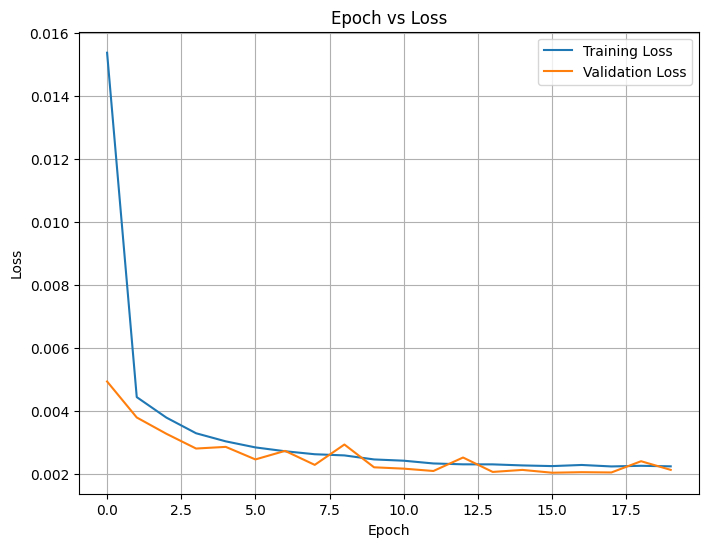

In [24]:
plt.figure(figsize = (8,6))
plt.plot(history.history["loss"],label = "Training Loss")
plt.plot(history.history["val_loss"],label = "Validation Loss")
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
model = load_model("best_jena_lstm.keras")
pred = model.predict(x_test)
pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y_test)

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [27]:
pred.shape

(42048, 1)

In [29]:
last = series[-TIME_STEPS:].reshape(1,TIME_STEPS,1)
next_temp = scaler.inverse_transform(model.predict(last))
print("Next Prediction:",next_temp[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Next Prediction: -5.0126247
